In [1]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="llama3.2:3b", temperature=0.2)

In [2]:
from langgraph.graph import MessagesState
from langchain.messages import RemoveMessage

# Function to call the model with the current messages
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

# Function to delete old messages if there are more than 10
def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [3]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(MessagesState)

# Nodes
graph.add_node("chat", chat)
graph.add_node("delete_old_messages", delete_old_messages)

# Edges
graph.add_edge(START, "chat")
graph.add_edge("chat", "delete_old_messages")
graph.add_edge("delete_old_messages", END)

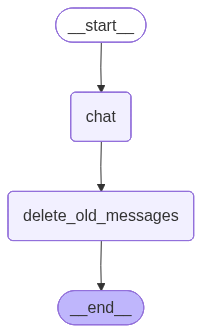

In [4]:
from langgraph.checkpoint.memory import InMemorySaver

saver = InMemorySaver()

workflow = graph.compile(checkpointer=saver)
workflow

In [5]:
# Configuration for thread ID
config = {"configurable": {"thread_id": "t1"}}

In [9]:
# Run multiple turns
result1 = workflow.invoke({"messages": [{"role": "user", "content": "Hi, I'm Hemant"}]}, config)
result1["messages"][-1].content

result2 = workflow.invoke({"messages": [{"role": "user", "content": "i Like To play cricket"}]}, config)
result2["messages"][-1].content

result3 = workflow.invoke({"messages": [{"role": "user", "content": "i also like coding"}]}, config)
result3["messages"][-1].content

result4 = workflow.invoke({"messages": [{"role": "user", "content": "What is My name"}]}, config)
result4["messages"][-1].content

result5 = workflow.invoke({"messages": [{"role": "user", "content": "my Home town is Mumbai"}]}, config)
result5["messages"][-1].content

result6 = workflow.invoke({"messages": [{"role": "user", "content": "What is My Home Town"}]}, config)
result6["messages"][-1].content

result7 = workflow.invoke({"messages": [{"role": "user", "content": "What i Like?"}]}, config)
result7["messages"][-1].content

"You like coding! We had a conversation earlier about how much you enjoy learning and working with different programming languages.\n\nIs there something specific that you're interested in or want to learn more about when it comes to coding?"

In [10]:
snap = workflow.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]), "\n")


Stored messages after cleanup: 10 



In [11]:
from langchain_core.messages import HumanMessage, AIMessage

messages = workflow.get_state(config).values["messages"]

for msg in messages:
    if isinstance(msg, HumanMessage):
        print("🧑Human:", msg.content)
        print("-" * 120)

    elif isinstance(msg, AIMessage):
        print("🤖AI:", msg.content)
        print("-" * 120)


🧑Human: i also like coding
------------------------------------------------------------------------------------------------------------------------
🤖AI: That's awesome, Hemant! Coding is a great skill to have, and it can be very rewarding to create something from scratch.

What programming languages do you enjoy learning and working with? Are you more into front-end development (e.g., HTML, CSS, JavaScript), back-end development (e.g., Python, Java, Ruby), or maybe mobile app development?

And are you part of any coding communities or groups in Mumbai that help you learn and stay updated on the latest developments in the field?
------------------------------------------------------------------------------------------------------------------------
🧑Human: What is My name
------------------------------------------------------------------------------------------------------------------------
🤖AI: I remember! Your name is Hemant. We had a nice conversation earlier, and I'm glad we could ch